In [1]:
%cd ..
# !dir 
import tangramlit as tg

C:\Users\enric\tangram\.venv\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


C:\Users\enric\tangram


C:\Users\enric\tangram\.venv\lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
C:\Users\enric\tangram\.venv\lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [2]:
import scanpy as sc
# import squidpy as sq

Retrieve true file path in drive through link:

In [2]:
!uv pip install winshell

Audited 1 package in 95ms


In [3]:
import winshell
import os

shortcut_path = r"H:/Il mio Drive/dati_per_enrico.lnk"
real_path = winshell.shortcut(shortcut_path).path

print(f"Real path: {real_path}")

# Now test it
if os.path.exists(real_path):
    print("Resolved path is accessible")
else:
    print("Resolved path is not available")

Real path: H:\.shortcut-targets-by-id\1UGLL2UOn-9s1OY1r9mGMc1RFF7REij9e\dati_per_enrico
Resolved path is accessible


In [10]:
%cd H:/Il mio Drive/

H:\Il mio Drive


In [ ]:
!dir /a

# Data loading

In [4]:
## Load pre-processed datasets
path = "H:/Il mio Drive"
adata_sc = sc.read_h5ad(path + "/data_tangram/counts100k_filt_pp_train_genes.h5ad")
adata_sc

AnnData object with n_obs × n_vars = 77337 × 253
    obs: 'nUMI', 'nGene', 'dataset', 'QC', 'cluster', 'Allen.cluster_id', 'Allen.cluster_label', 'Allen.cluster_color', 'Allen.class_label', 'Allen.subclass_label', 'comb.QC', 'train_set', 'test_set'
    var: 'gene_ids', 'feature_types', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'spapros_probe', 'sparsity'
    uns: 'hvg', 'neighbors', 'pca', 'training_genes', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [5]:
adata_st = sc.read_h5ad(path + "/data_tangram/slice200_pp.h5ad")
adata_st

AnnData object with n_obs × n_vars = 2133 × 254
    obs: 'sample_id', 'slice_id', 'class_label', 'subclass', 'label', 'instance_id', 'centroid_x', 'centroid_y', 'region'
    var: 'is_sequential', 'is_combinatorial', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'sparsity'
    uns: 'gearyC', 'hvg', 'log1p', 'moranI', 'spatial_neighbors', 'spatialdata_attrs', 'training_genes'
    obsm: 'spatial'
    obsp: 'spatial_connectivities', 'spatial_distances'

# Loss coefficients: $\lambda$s
Depending on the mode (cells or conrtained) the Tangram loss function has either up to 4 or up to 6 regularization coefficients. These coefficients scale (are multiplied to) each single term of the Loss and are quite necessary, since loss terms are defined heuristically and are not in the same order of magnitude by default. In fact quite the opposite is true: cosine similarity terms map into [-1, 1] by definition (and their mean as well), KL divergence is non-negative but with no upper bound, the entropy regularizer has no bound as well and filtering related terms are in the order of magnitude equal the number of target cells (i.e., number of spots).



For this reason, an initial set of coefficients that ensures all terms live approximately on the same scale is required. To do so, one can first run a naive unitary set and, based on visual inspection, retrieve the orders of magnitude and adjust accordingly. Alternatively, the values could be automatically set to match the order of magnitude of the terms in the first training step (as soon as the initial value of each term is available) and auto-adjust.

Subsequently, one can either turn off loss terms at will by assigning the corresponding coefficient a value of 0 or create a custom set based off of loss behaviour and mapping results.

## Baseline model
A baseline model, with all $\lambda$s set to 1, is trained for a few epochs to evaluate the order of magnitude of each loss term for the different modes available:

### Vanilla mode

In [9]:
ad_map_baseline, mapper_baseline, data_baseline = tg.map_cells_to_space(
        adata_sc, 
        adata_st, 
        mode='vanilla',
        learning_rate=0.1,
        num_epochs=10,
        lambda_d=1,
        lambda_g1=1,
        lambda_g2=1,
        lambda_r=1,
        lambda_l1=1,
        lambda_l2=1,
        random_state=42,
        )

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name               | Type      | Params | Mode 
---------------------------------------------------------
0 | _density_criterion | KLDivLoss | 0      | train
  | other params       | n/a       | 164 M  | n/a  
---------------------------------------------------------
164 M     Trainable params
0         Non-trainable params
164 M     Total params
659.839   Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode


Training: |                                                                                      | 0/? [00:00<…

Training with 252 genes
S matrix shape: torch.Size([77337, 252])
G matrix shape: torch.Size([2133, 252])


`Trainer.fit` stopped: `max_epochs=10` reached.


Initial value of total_loss 297163904.0
Initial value of main_loss 0.5169236660003662
Initial value of vg_reg 0.5126924514770508
Initial value of kl_reg 1.1752592399716377e-05
Initial value of entropy_reg -554207.9375
Initial value of l1_term 131630208.0
Initial value of l2_term 164979488.0


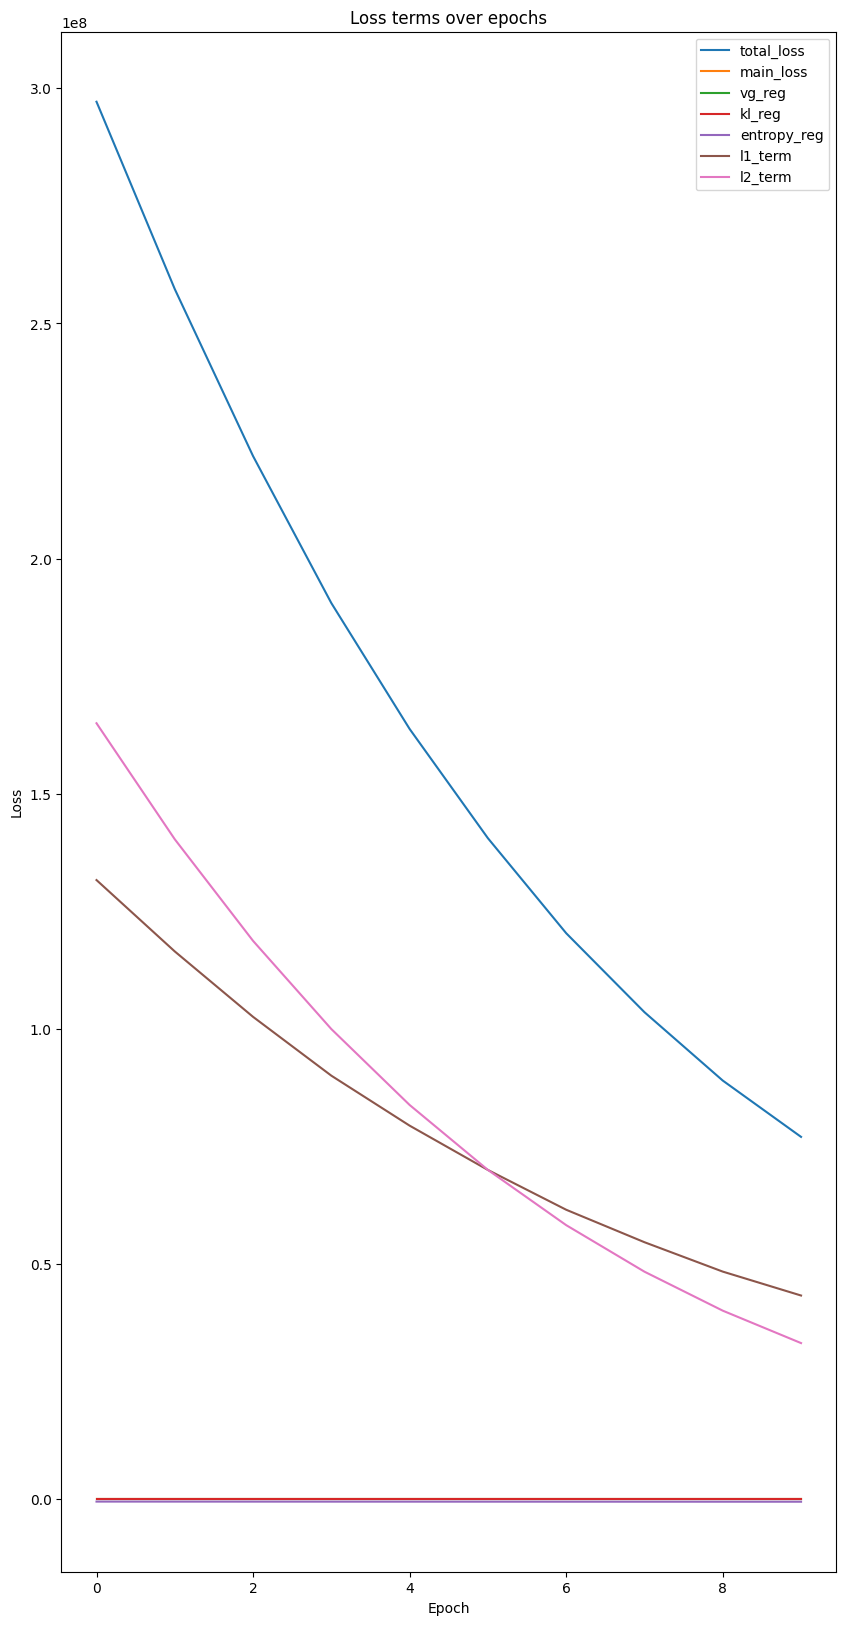

In [12]:
# Plot loss terms
for term in ad_map_baseline[0].uns['training_history'].keys():
    value = ad_map_baseline[0].uns['training_history'][term][0]
    print("Initial value of", term, value)
    
tg.plot_training_history(adata_map=ad_map_baseline, hyperpams=mapper_baseline.hparams,
                   log_scale=False, lambda_scale=False)

As we can see initial values are all over the place in terms of scale. $\mathcal{l}-norm$ regularizers reach huge orders of magnitudes, followed by the entropy regularizer; all summing the whole mapping matrix $M$ into a scalar.

### Filter mode

In [15]:
ad_map_baseline_filt, mapper_filt, data_filt = tg.map_cells_to_space(
    adata_sc, 
    adata_st, 
    mode='filter',
    learning_rate=0.1,
    num_epochs=10,
    lambda_d=1,
    lambda_g1=1,
    lambda_g2=1,
    lambda_r=0,
    lambda_l1=0,
    lambda_l2=0,
    lambda_count=1,
    lambda_f_reg=1,
    target_count=None,
    random_state=42,
    )

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name               | Type      | Params | Mode 
---------------------------------------------------------
0 | _density_criterion | KLDivLoss | 0      | train
  | other params       | n/a       | 165 M  | n/a  
---------------------------------------------------------
165 M     Trainable params
0         Non-trainable params
165 M     Total params
660.149   Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode


Training: |                                                                                      | 0/? [00:00<…

Training with 252 genes
S matrix shape: torch.Size([77337, 252])
G matrix shape: torch.Size([2133, 252])


`Trainer.fit` stopped: `max_epochs=10` reached.


Initial value of total_loss 52463.3359375
Initial value of main_loss 0.5169240832328796
Initial value of vg_reg 0.5125992298126221
Initial value of kl_reg 1.3388926163315773e-05
Initial value of entropy_reg -0.0
Initial value of l1_term 0.0
Initial value of l2_term 0.0
Initial value of count_reg 36486.3515625
Initial value of lambda_f_reg 15978.017578125


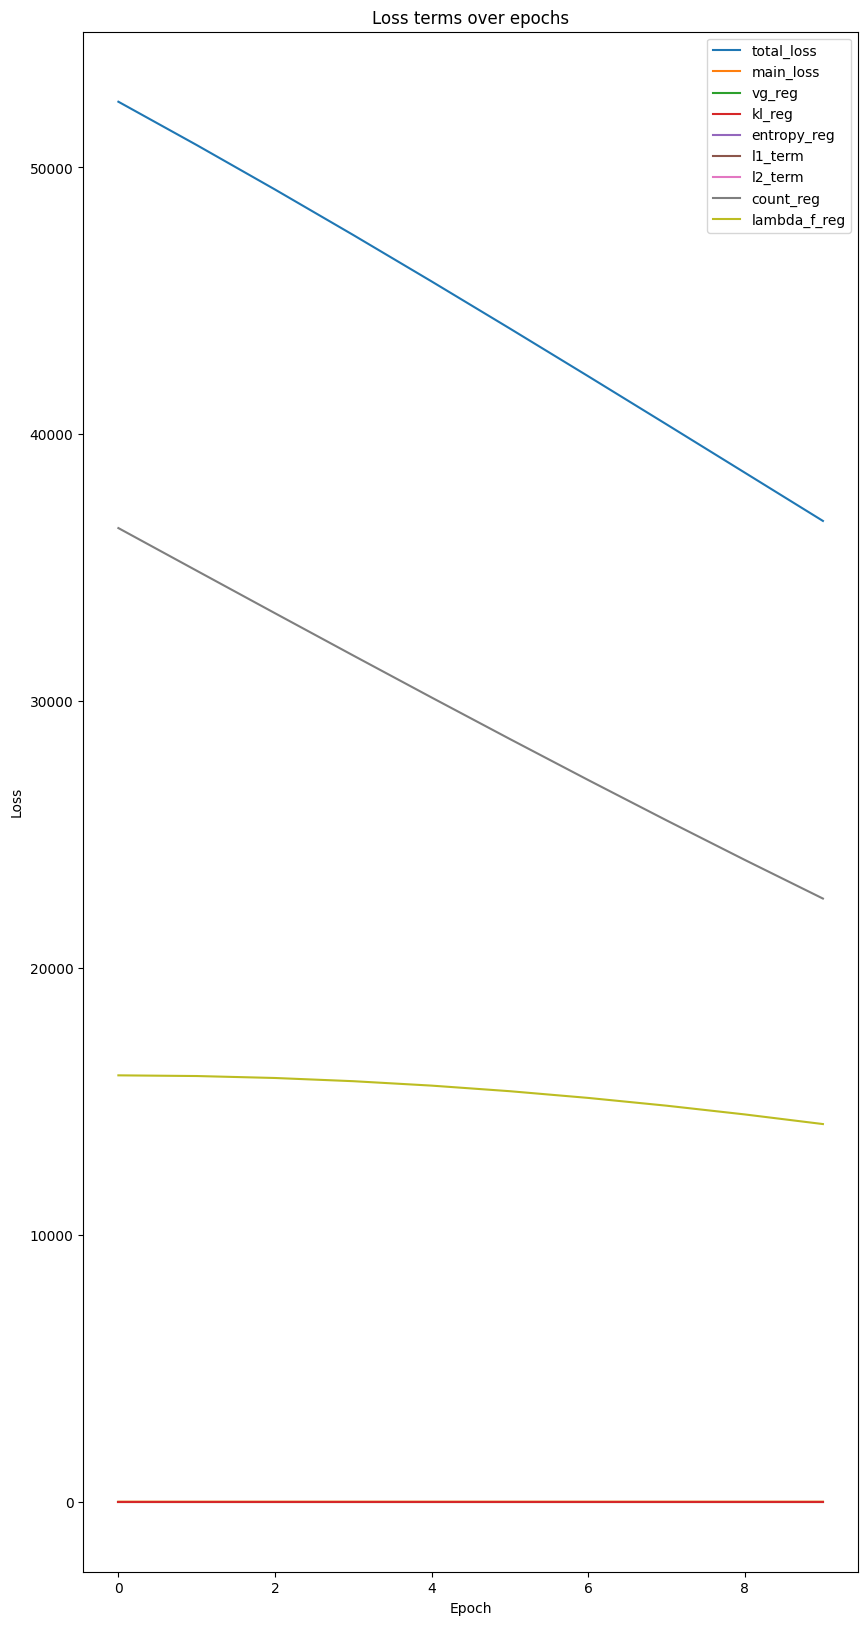

In [16]:
# Plot loss terms
for term in ad_map_baseline_filt.uns['training_history'].keys():
    value = ad_map_baseline_filt.uns['training_history'][term][0]
    print("Initial value of", term, value)
    
tg.plot_training_history(adata_map=ad_map_baseline_filt, hyperpams=mapper_filt.hparams,
                   log_scale=False, lambda_scale=False)

Same here with very distant scales. Filter terms are on a different scales, compared to everything else.

### Refined mode

In [ ]:
'spatial_connectivities' in adata_st.obsp.keys()

In [ ]:
ad_map_baseline_ref, mapper_ref, data_ref = tg.map_cells_to_space(
    adata_sc, 
    adata_st, 
    mode='refined',
    learning_rate=0.1,
    num_epochs=10,
    lambda_d=0,
    lambda_g1=1,
    lambda_g2=1,
    lambda_r=0,
    lambda_l1=0,
    lambda_l2=0,
    lambda_sparsity_g1=1,
    lambda_neighborhood_g1=1,
    lambda_getis_ord=1,
    lambda_moran=1,
    lambda_geary=1,
    lambda_ct_islands=1,
    cluster_label='Allen.class_label',
    random_state=42,
    )

In [ ]:
# Plot loss terms
for term in ad_map_baseline_ref.uns['training_history'].keys():
    value = ad_map_baseline_ref.uns['training_history'][term][0]
    print("Initial value of", term, value)
    
tg.plot_training_history(adata_map=ad_map_baseline_ref, hyperpams=mapper_ref.hparams,
                   log_scale=False, lambda_scale=False)

## Automatic coefficients
In this section we develop a function that automatically computes a suitable set of regularization hyperparameters, based on the scale of the existing input arguents to the mapping function.

* We know that all cosine similarity terms are, by definition, bounded in the $[-1, 1]$ interval and can possibly be shifted into $[0,2]$ by settig loss terms as $1-cossim()$. This would also turn the problem into a direct minimization instead of a negative maximization. Note that this is true because the loss terms are obtained as the average similarity over the rows/columns of the spatial matrices, alternatively one could use the sum, which would make the magnitude dependent on the input data size.

* The KL term has, by definition, a lower bound of 0 that is, ideally, approached during the optimization. The initial value depends on both the prior distribution d (usually uniform) and the starting estimate m, which depends on the IC for the matrix M. One can try to analytically extract an upper bound based on the initial estimated distribution.

* The entropy regularizer term is theoretically upper bounded by a uniform distribution over the values of M.

* The target count term initial value depends on the absolute number of cells in both datasets and the initial conditions of the filter. i.e. the expected value of the sum of its entries.

* The filter regularizer initial value can be described by a transformation of the expected value of the sum of the filter terms.

* Refinement term have scales depending mainly on the weighting matrices' magnitudes.

The problem is then to determine what is the optimal scale to move everything in: one could move all terms into the unitary ($10^0$) magnitude or a larger/smaller one. The core idea is that the order of magnitude affects losses absolute values and consequenlty all the gradient values. Ultimately, this affects the optimization only for basic algorithms that to not includean adaptive learning rate (like standard SDG), where the scale factor acts on the learning rate itself. Optimizers with an adaptive learning eate, like Adam,  are scale invariant so the problem is mitigated already.

## Optuna Search
In the Refinements paper, loss terms' coefficients, which are in fact hyperparameters of the mapper, are tuned with an **Optuna** grid search, with the objective of maximizing several multiple-run consistency metrics.

# Vanilla Model
Now that a reasonable set of hyperparamters is identified, we proceed by fully trainig the Vanilla model.

## KL Divergence
For single cell resolution spatial technologies, the simplest, but most reasonable, prior distribution of cell density over spots is the **Uniform** distribution. This comes directly from the fact that each spatial spot corresponds to a unique cell, thus alternatives like the *RNA count based density* (computed on the expression levels) does not make sense.

Despite the theoretical foundation, it appears that this term is of relative importance: its initial value, which one can derive analitically as the expected value of a sum of Normal variables subtraced to a uniform one, is already very small and does not increase any further.

This highlights the stability of the convergence and implies that this term might act as a "constraint" (forcing the distribution to not diverge from the prior) rather than being a strong training force.

In the case of pre-annotated spatial data, one could exploit such annotations to condition the prior.

# Loss behaviour and Optimization

## Loss Landscape
One of the most prominent features of Tangram as a non-convex optimization problem is that it does not implement minibatching, as it learns the whole projection matrix at each training step, using all datapoints. 

This implies that the gradient is computed on the whole dataset with no effective stochastic component, translating into extremely smooth loss trajectories.

The smoothness of the loss landscape is not reliant on this fact per se, but having a deterministic gradient signal allows to asses this quality much more directly. In fact, only a few terms exhibit a rougher trajectory.

Moreover, the loss function has terms that live on distinct parameter spaces, namely:
* All filterm terms depend only on the filter entries $f$
* The entropy and $\mathcal{l}-norm$ regularizer terms and depend only on the unfiltered (softmax) projection matrix $M$;
*  All the other terms depend on the joint parameters space of the filtered matrix $M$ (if filtering is applied), namely the original cosine similarities, their refined weightings and the KL divergence.

When filtering is not implemented, the parameter space contains only the matrix $M$.


## Optimizer
With SGD no improvement in the loss is seen even after 200 epochs (completely stagnating gradient).

To further investigate it might be worth trying other initial conditions (perhaps base them on the final values that the M matrix with no softmax or filtering converges to and if they're coherent with the initial values).
Another aspect is the optimizer: ADAM works well, so first one can introduce momentum and see if it help escaping the flat zone quicker and secondly introduce adaptive learning rates and study theur behavior (how do they move in the loss landscape).

Anyhow, loss terms seem to have a pretty smooth trajectory with quite fast convergence when using ADAM.

The main reason why SGD might not work is that Tangram does not implement minibatches, as explained above. This implies that the gradient is computed on the whole dataset with no effective stochastic component that usually ensures the optimizer to explore more rapidly the loss landscape. Adding momentum could help accelerate but an adaptive learning rate is clearly the best approach.

Another reason for adaptive learning rates is the scale problem mentioned above: with this approach the magnitued of the gradient is scaled automatically preventing large terms to overtake completely the gradient descent. The issue of scales persists only at the beginning, when Adam has not yet adjusted the scales.

The presence of a joint parameters space (section above) also argues in favor of a (single) adaptive optimizer as the best choice, as it can separate the learning process in the parameters sub-spaces.

## Learning rate
Given the smoothness of the loss landscape, it appears reasonable to adopt a larger learning rate to favour a faster convergence.

Smaller rates and additional scheduling are most suitable for complex and rough landscapes, where one can identify optimization phases with a different pace and a variable convergence.

Here, such behaviour is not observed, but a scheduler that reduces the rate on plateau is implemented anyway. One might train the model without it for comparison.

In [ ]:
ad_map_baseline, mapper_baseline, data_baseline = tg.map_cells_to_space(
        adata_sc, 
        adata_st, 
        mode='vanilla',
        learning_rate=0.1,
        num_epochs=10,
        lambda_d=1,
        lambda_g1=1,
        lambda_g2=1,
        lambda_r=1,
        lambda_l1=1,
        lambda_l2=1,
        random_state=42,
        )

# Initial Conditions
Tangram initializes both its parameter sets as Standard Distributions: $M, \ f  \sim \mathcal{N}(0,1)$.

Subsequenly, in the forward pass, the matrix $M$ goes through a **softmax** layer, while the filter $f$ goes throug a **sigmoid** activation.

Theoretical results on the output distribution on both these operations can be exploited to gain insight in the expected distribution of "forwarded" parameters.

## Mapping Matrix ICs

More in general, we could try different initialization approaches and see how the distribution type and parameters affect the optimization (e.g., can it affect sparsity of the $M$ matrix and so on).

## Filter ICs
in this section we asses whether the IC of the filter affect its final values and, if so, how much. 

One way to see this is to check if the filter values of the cells that are "selected" at the end (have high confidence) correlate to ther initial values, i.e. if the initial values biases the selection.

In [16]:
ad_map_filt, mapper_filt, datamodule_filt = tg.map_cells_to_space(
    adata_sc=adata_sc, 
    adata_st=adata_st, 
    mode='filter',
    num_epochs=100,
    lambda_d=1,
    lambda_g1=1,
    lambda_g2=1,
    lambda_r=0,
    lambda_l1=0,
    lambda_l2=0,
    lambda_count=1e-4,
    lambda_f_reg=1e-3,
    random_state=123,
    )

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name               | Type      | Params | Mode 
---------------------------------------------------------
0 | _density_criterion | KLDivLoss | 0      | train
  | other params       | n/a       | 165 M  | n/a  
---------------------------------------------------------
165 M     Trainable params
0         Non-trainable params
165 M     Total params
660.149   Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode


Training: |                                                                                      | 0/? [00:00<…

Training with 252 genes
S matrix shape: torch.Size([77337, 252])
G matrix shape: torch.Size([2133, 252])


`Trainer.fit` stopped: `max_epochs=100` reached.


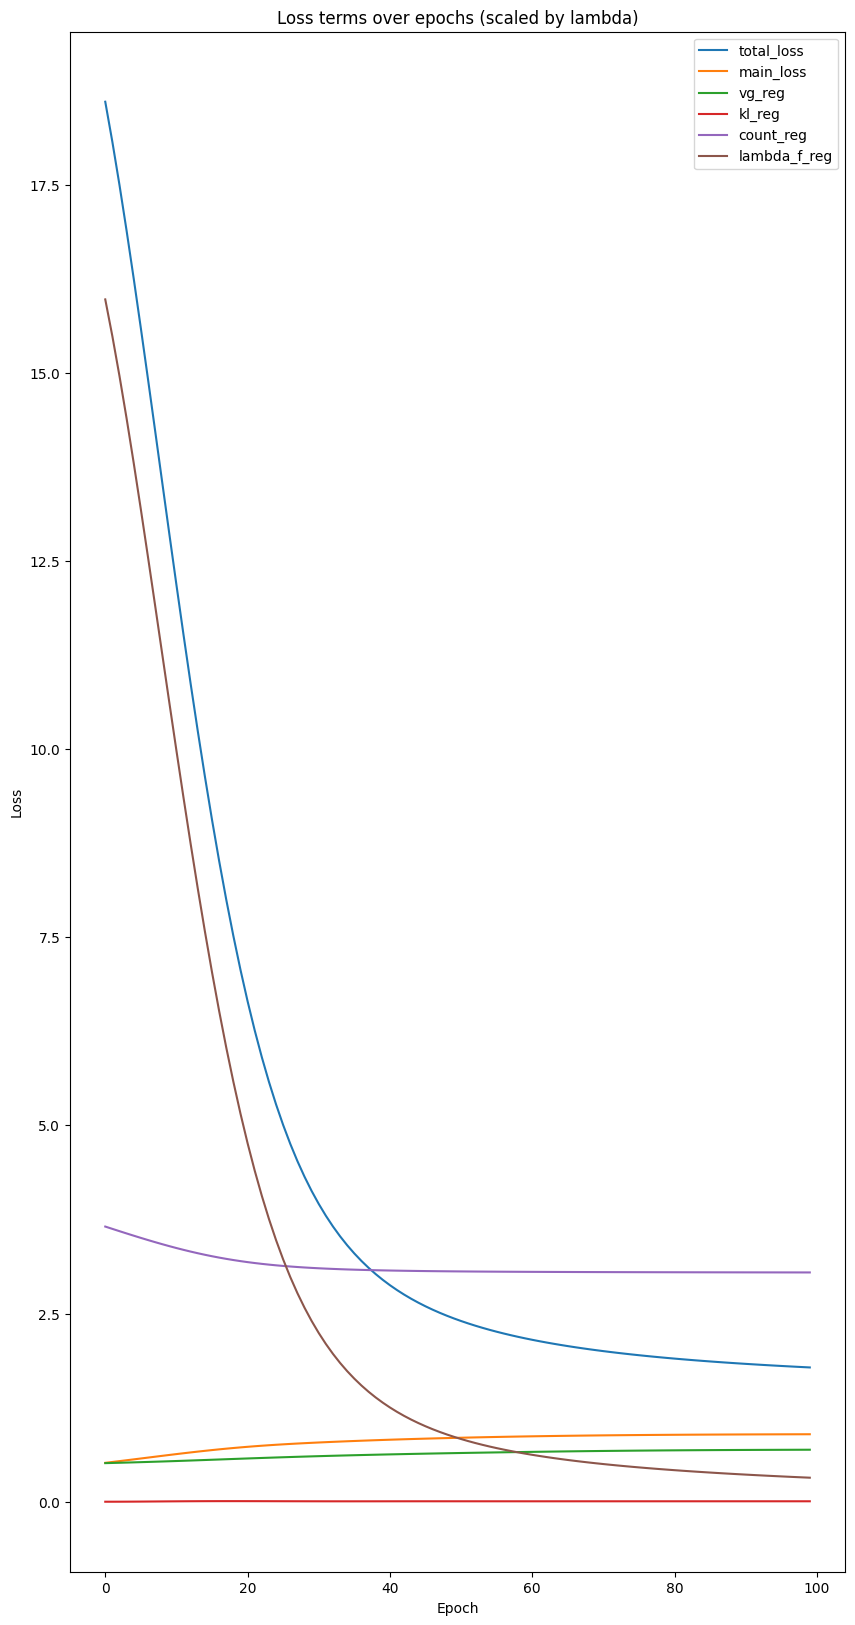

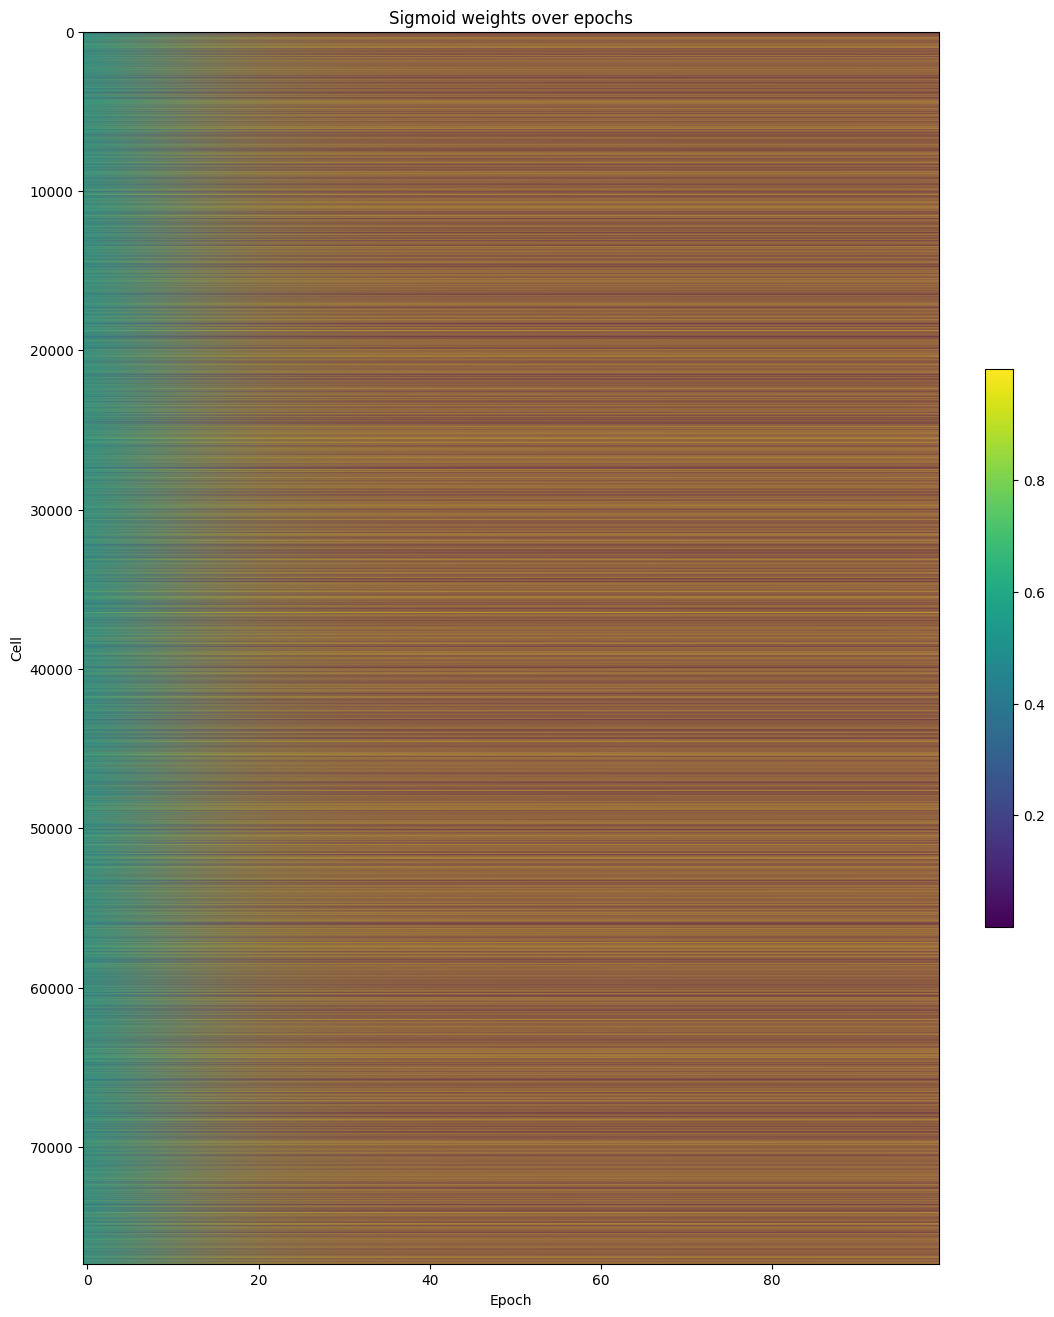

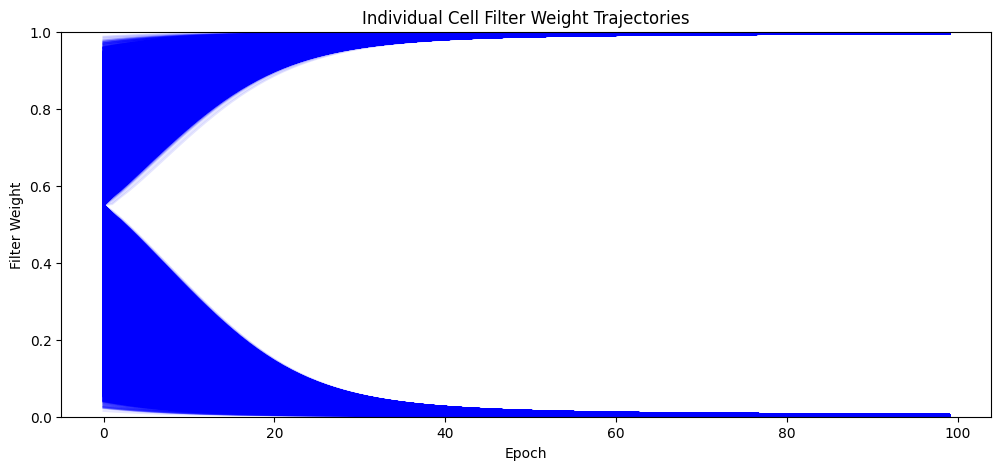

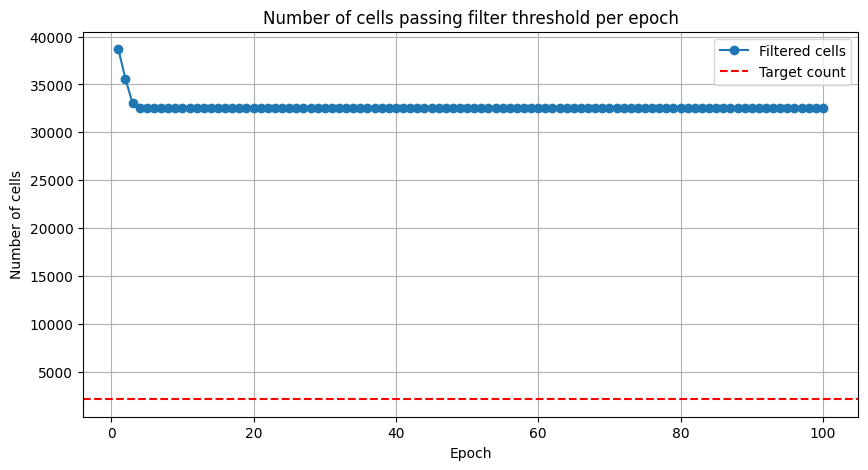

In [17]:
# Plot loss terms
tg.plot_training_history(adata_map=ad_map_filt, hyperpams=mapper_filt.hparams, log_scale=False)
# tg.plot_training_history(adata_map=ad_map_filt, hyperpams=mapper_filt.hparams, log_scale=False, lambda_scale=False)

# Plot final filter values distribution
tg.plot_filter_weights(ad_map_filt, plot_spaghetti=True, plot_envelope=False)
tg.plot_filter_count(ad_map_filt, target_count=None)

Pearson correlation coefficient of filter values: 0.8324195557222567


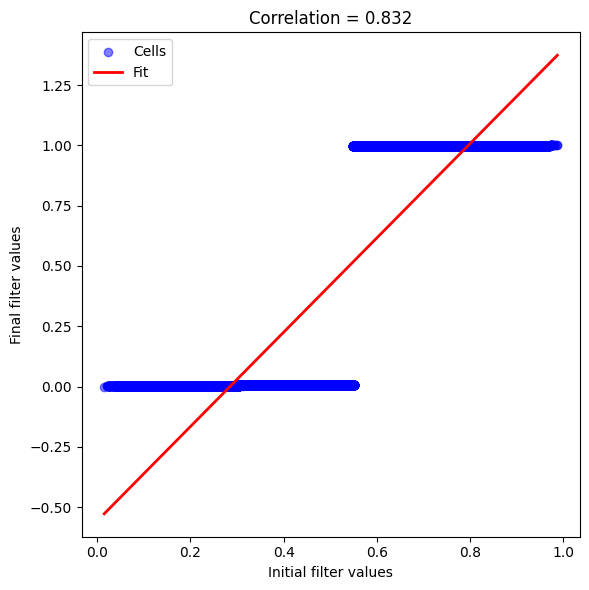

In [18]:
filt_corr = tg.compute_filter_corr(ad_map_filt)

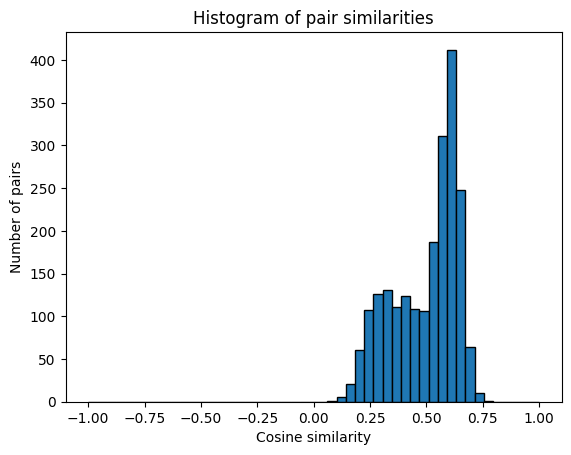

In [19]:
filt_sim = tg.compute_mapped_similarity(ad_map_filt, adata_sc, adata_st, 
                                       flavour='spot_to_cell', filter=True)

In [13]:
print(adata_sc.obs.keys())
print(adata_st.obs.keys())

Index(['nUMI', 'nGene', 'dataset', 'QC', 'cluster', 'Allen.cluster_id',
       'Allen.cluster_label', 'Allen.cluster_color', 'Allen.class_label',
       'Allen.subclass_label', 'comb.QC', 'train_set', 'test_set'],
      dtype='object')
Index(['sample_id', 'slice_id', 'class_label', 'subclass', 'label',
       'instance_id', 'centroid_x', 'centroid_y', 'region'],
      dtype='object')


In [15]:
filt_acc = tg.compute_annotation_accuracy(
        ad_map_filt,
        adata_sc,
        adata_st,
        flavour='spot_to_cell',
        sc_cluster_label='Allen.subclass_label',
        st_cluster_label='subclass',
        filter=True,
)

KeyError: 'class_label'

# Model testing

## Vanilla mode

In [ ]:
ad_map, _, _ = tg.map_cells_to_space(
    adata_sc=adata_sc, 
    adata_st=adata_st, 
    mode='vanilla',
    num_epochs=300,
    lambda_d=1,
    lambda_g1=0.5,
    lambda_g2=0.5,
    lambda_r=0.0003,
    lambda_l1=0.01,
    lambda_l2=0.01,
    random_state=42,
    )

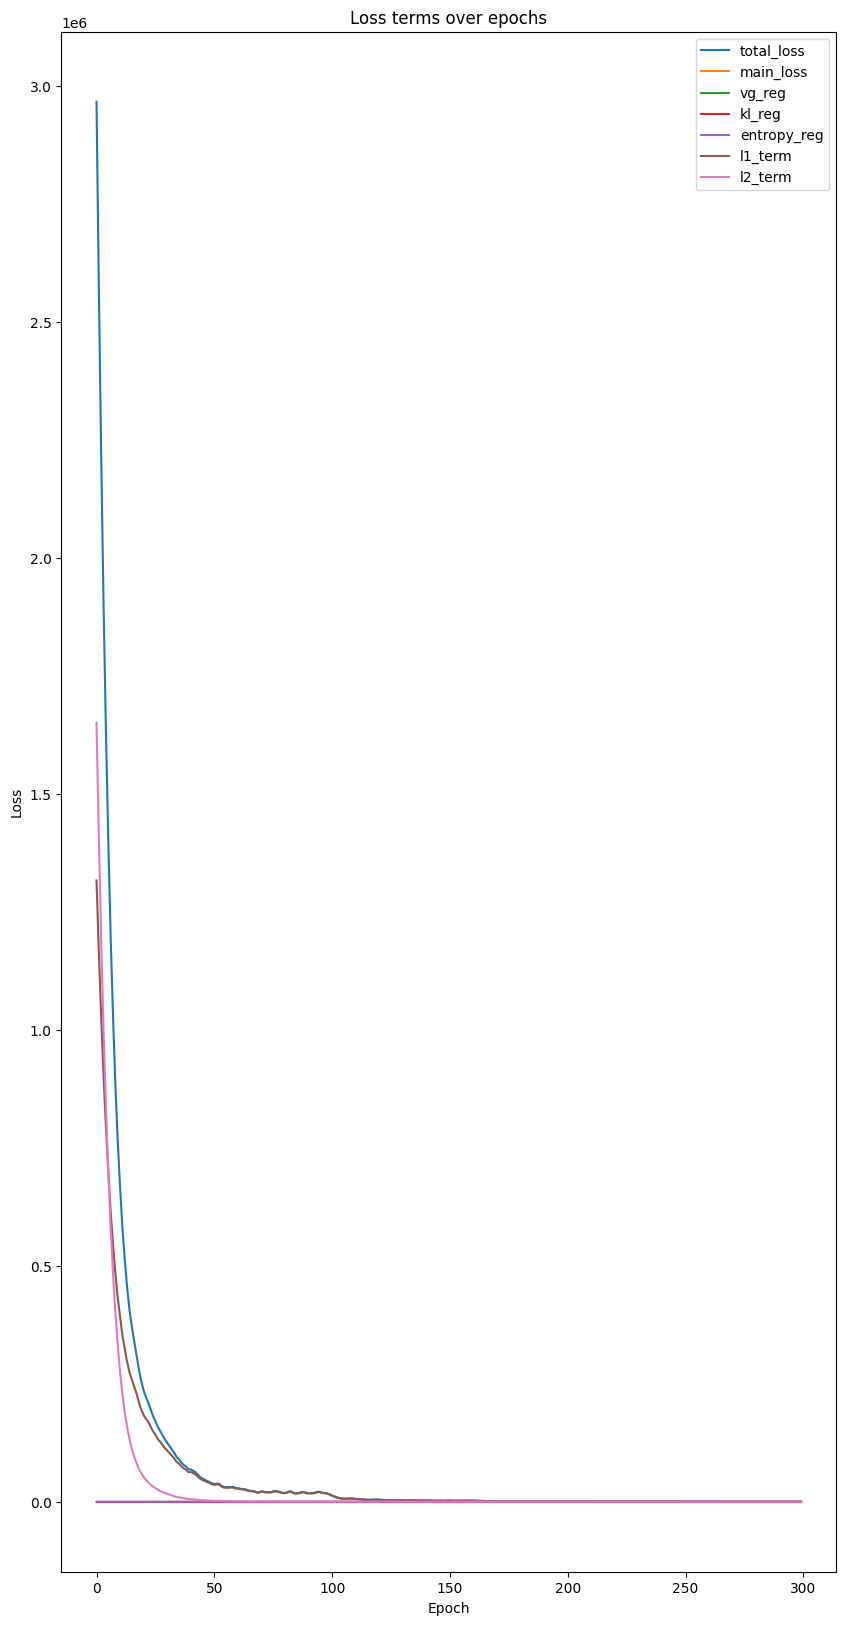

In [10]:
# Plot loss terms
tg.plot_training_history(adata_map=ad_map, log_scale=False)

## Refined mode

In [18]:
'spatial_connectivities' not in adata_st.obsp.keys()

False

In [14]:
ad_map_ref, _, _ = tg.map_cells_to_space(
    adata_sc=adata_sc, 
    adata_st=adata_st, 
    mode='refined',
    num_epochs=30,
    lambda_d=1,
    lambda_g1=1,
    lambda_g2=0,
    lambda_r=0,
    lambda_l1=0,
    lambda_l2=0,
    lambda_sparsity_g1=1,
    lambda_neighborhood_g1=1,
    lambda_getis_ord=1,
    lambda_moran=1,
    lambda_geary=1,
    lambda_ct_islands=1,
    cluster_label='Allen.subclass_label',
    random_state=42,
    )

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name               | Type      | Params | Mode 
---------------------------------------------------------
0 | _density_criterion | KLDivLoss | 0      | train
  | other params       | n/a       | 164 M  | n/a  
---------------------------------------------------------
164 M     Trainable params
0         Non-trainable params
164 M     Total params
659.839   Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode


Training: |                                                                                      | 0/? [00:00<…

Training with 252 genes
S matrix shape: torch.Size([77337, 252])
G matrix shape: torch.Size([2133, 252])


RuntimeError: [enforce fail at alloc_cpu.cpp:116] data. DefaultCPUAllocator: not enough memory: you tried to allocate 4586086512 bytes.